In [1]:
import torch
from torchvision import datasets, transforms

transform = transforms.Compose([transforms.ToTensor(),
                              transforms.Normalize((0.5,), (0.5,)),
                              ])
# Download and load the training data
trainset = datasets.MNIST('MNIST_data_train/', download=True, train=True, transform=transform)
testset = datasets.MNIST('MNIST_data_test/', download=True, train=False, transform=transform)

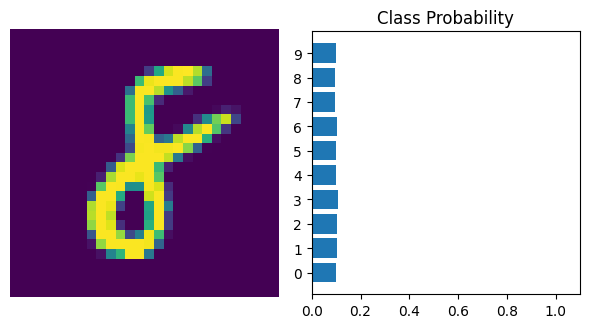

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from ConvolutionalSelfAttention.utils.modules import *
from ConvolutionalSelfAttention.utils.benchmark_models import *
from ConvolutionalSelfAttention.utils.benchmark_pipe import *
from ConvolutionalSelfAttention.utils.data_load_test import *
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
model = MNIST_CSA_1_layer(1, (28*28))

# Grab some data
dataiter = iter(trainloader)
images, labels = next(dataiter)
images.resize_(64, 1, 1, 28, 28)
img_idx = 0
pred, embed = model.forward(images[img_idx,:])
ps = F.log_softmax(pred, dim=1)
img = images[img_idx]

view_classify(img.view(1, 28, 28), torch.exp(ps))

In [4]:
model = MNIST_CSA_1_layer(1, (28*28)).to('cuda')
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=True)
csa_1_loss, csa_1_time = run_test(model, trainloader, testloader, '')

  6%|▌         | 12/200 [02:05<32:47, 10.47s/it]
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x1555514dd570>>
Traceback (most recent call last):
  File "/home/phjiang/.conda/envs/convSelfAtten/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


KeyboardInterrupt: 

In [ ]:
model = MNIST_CSA_1_layer(1, (28*28)).to('cuda')
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=True)
csa_1_loss, csa_1_time = run_test(model, trainloader, testloader, '')